<a href="https://colab.research.google.com/github/Sharif2138/African-Language-Health-QA-Challenge/blob/main/Exp6_7_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 6: Efficient Prompt Engineering

## What Went Wrong in Experiment 5

Experiment 5 used a long instruction prefix:

    "You are a health expert. Answer the following question in Akan.
     Question: {question}
     Answer:"

This added ~25 tokens to every input. With MAX_INPUT_LENGTH=128,
the actual question was getting truncated — the model never saw the
full question it was supposed to answer. The result was lower ROUGE
(0.142 vs 0.1638) and outputs that copied fragments from the prompt.

## The Fix

We keep the prompt engineering idea but use a minimal prefix that
adds only 4-5 tokens:

    "health qa {language}: {question}"

This gives the model:
- Task signal: "health qa" tells it this is a health QA task
- Language signal: the full language name tells it what to generate in
- The complete question: nothing gets truncated

We also increase MAX_INPUT_LENGTH from 96 to 128 to give extra
headroom for non-English scripts which tokenize into more subwords
than English.

## Hypothesis

A short efficient prompt that preserves the full question will
outperform both the long prompt (Exp 5) and the raw question
baseline (Exp 4), combining the language signal benefit with
full question visibility.

In [ ]:
!pip install -q torchao==0.16.0
!pip install -q transformers datasets evaluate accelerate peft sentencepiece rouge-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 56.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00


In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import transformers
from datasets import Dataset
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)
from peft import LoraConfig, TaskType, get_peft_model
from torch.utils.data import DataLoader

transformers.logging.set_verbosity_error()

In [ ]:
train_small = pd.read_csv("/content/drive/MyDrive/datasets/train_small2.csv")
val_small   = pd.read_csv("/content/drive/MyDrive/datasets/val_small2.csv")
test        = pd.read_csv("/content/drive/MyDrive/datasets/test_clean.csv")

LANGUAGE_MAP = {
    "Aka_Gha": "Akan",
    "Amh_Eth": "Amharic",
    "Lug_Uga": "Luganda",
    "Swa_Ken": "Swahili",
    "Eng_Eth": "English",
    "Eng_Gha": "English",
    "Eng_Ken": "English",
    "Eng_Uga": "English"
}

def apply_prompt(df):
    df = df.copy()
    df["input"] = df.apply(
        lambda row: f"health qa {LANGUAGE_MAP[row['subset']]}: {row['input']}",
        axis=1
    )
    return df

train_small = apply_prompt(train_small)
val_small   = apply_prompt(val_small)
test        = apply_prompt(test)

train_ds = Dataset.from_pandas(train_small)
val_ds   = Dataset.from_pandas(val_small)
test_ds  = Dataset.from_pandas(test)

print("train_ds:", len(train_ds))
print("val_ds  :", len(val_ds))
print("test_ds :", len(test_ds))
print()
print("Sample prompted input:")
print(train_small["input"].iloc[0])

train_ds: 4000
val_ds  : 1200
test_ds : 2618

Sample prompted input:
health qa Akan: Mɛyɛ dɛn ahu sɛ nna ne abusuabɔ ho nsɛm a ɛwɔ Intanɛt so no yɛ nokware, na wotumi de ho to so?


In [ ]:
MODEL_NAME        = "google/mt5-small"
MAX_INPUT_LENGTH  = 128
MAX_TARGET_LENGTH = 192

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("pad_token_id:", tokenizer.pad_token_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

pad_token_id: 0


In [ ]:
def tokenize(examples):
    inputs = tokenizer(
        examples["input"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )
    targets = tokenizer(
        text_target=examples["output"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding=False
    )
    inputs["labels"] = [
        [t if t != tokenizer.pad_token_id else -100 for t in ids]
        for ids in targets["input_ids"]
    ]
    return inputs

def tokenize_test(examples):
    return tokenizer(
        examples["input"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )

tok_train = train_ds.map(tokenize,     batched=True, remove_columns=train_ds.column_names)
tok_val   = val_ds.map(tokenize,       batched=True, remove_columns=val_ds.column_names)
tok_test  = test_ds.map(tokenize_test, batched=True, remove_columns=test_ds.column_names)

print(tok_train)
print()

# Verify nothing is being truncated aggressively
lengths = [len(x) for x in tok_train["input_ids"]]
print(f"Input lengths — mean: {np.mean(lengths):.0f} | "
      f"95th pct: {np.percentile(lengths, 95):.0f} | "
      f"max: {max(lengths)}")

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/2618 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 4000
})

Input lengths — mean: 34 | 95th pct: 74 | max: 128


In [ ]:
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
model = model.float()

model.config.decoder_start_token_id = tokenizer.pad_token_id
model.config.forced_bos_token_id    = None

lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=4,
    lora_alpha=8,
    lora_dropout=0.1,
    target_modules=["q", "v"],
    bias="none"
)

model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

trainable params: 172,032 || all params: 300,348,800 || trainable%: 0.0573


In [ ]:
collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
    pad_to_multiple_of=8
)

In [ ]:
rouge = evaluate.load("rouge")

def clean(text):
    return re.sub(r"<extra_id_\d+>", "", text).strip()

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    preds  = np.clip(preds, 0, tokenizer.vocab_size - 1)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_preds  = [clean(t) for t in
                      tokenizer.batch_decode(preds,  skip_special_tokens=True)]
    decoded_labels = tokenizer.batch_decode(labels,  skip_special_tokens=True)
    scores = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )
    return {
        "ROUGE1": round(scores["rouge1"], 4),
        "ROUGEL": round(scores["rougeL"], 4)
    }

In [ ]:
args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/checkpoints/exp6",

    num_train_epochs=3,
    learning_rate=3e-4,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,

    weight_decay=0.01,
    max_grad_norm=1.0,

    fp16=False,
    bf16=False,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="ROUGE1",
    greater_is_better=True,

    generation_max_length=192,
    generation_num_beams=1,

    predict_with_generate=True,

    logging_strategy="steps",
    logging_steps=25,
    save_total_limit=1,
    dataloader_num_workers=0,
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=tok_train,
    eval_dataset=tok_val,
    data_collator=collator,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

{'loss': '49.11', 'grad_norm': '498.2', 'learning_rate': '0.0002904', 'epoch': '0.1'}
{'loss': '45.31', 'grad_norm': '687.4', 'learning_rate': '0.0002804', 'epoch': '0.2'}
{'loss': '36.4', 'grad_norm': '373.5', 'learning_rate': '0.0002704', 'epoch': '0.3'}
{'loss': '28.87', 'grad_norm': '133.1', 'learning_rate': '0.0002604', 'epoch': '0.4'}
{'loss': '23.43', 'grad_norm': '509.6', 'learning_rate': '0.0002504', 'epoch': '0.5'}
{'loss': '20.45', 'grad_norm': '28.5', 'learning_rate': '0.0002404', 'epoch': '0.6'}
{'loss': '18.15', 'grad_norm': '23.26', 'learning_rate': '0.0002304', 'epoch': '0.7'}
{'loss': '16.43', 'grad_norm': '24.27', 'learning_rate': '0.0002204', 'epoch': '0.8'}
{'loss': '15.46', 'grad_norm': '7.319', 'learning_rate': '0.0002104', 'epoch': '0.9'}
{'loss': '14.8', 'grad_norm': '18.99', 'learning_rate': '0.0002004', 'epoch': '1'}
{'eval_loss': '5.569', 'eval_ROUGE1': '0.0392', 'eval_ROUGEL': '0.0365', 'eval_runtime': '602.6', 'eval_samples_per_second': '1.992', 'eval_steps

TrainOutput(global_step=750, training_loss=17.022362467447916, metrics={'train_runtime': 2425.6033, 'train_samples_per_second': 4.947, 'train_steps_per_second': 0.309, 'train_loss': 17.022362467447916, 'epoch': 3.0})

In [ ]:
trainer.save_model("/content/drive/MyDrive/models/exp6/best_model")
tokenizer.save_pretrained("/content/drive/MyDrive/models/exp6/best_model")
print("Model saved")

Model saved


In [ ]:
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

val_loader = DataLoader(
    tok_val,
    batch_size=8,
    collate_fn=DataCollatorForSeq2Seq(
        tokenizer=tokenizer,
        model=model,
        padding=True,
        pad_to_multiple_of=8
    )
)

pred_text = []
ref_text  = []

for batch in val_loader:
    input_ids      = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels         = batch["labels"]

    with torch.no_grad():
        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=192,
            num_beams=1,
            decoder_start_token_id=tokenizer.pad_token_id,
            forced_bos_token_id=None,
            no_repeat_ngram_size=3
        )

    pred_text.extend([
        clean(t) for t in
        tokenizer.batch_decode(outputs, skip_special_tokens=True)
    ])

    labels = torch.where(labels != -100, labels, tokenizer.pad_token_id)
    ref_text.extend(
        tokenizer.batch_decode(labels, skip_special_tokens=True)
    )

print(f"Generated {len(pred_text)} predictions")

Generated 1200 predictions


In [ ]:
scores = rouge.compute(
    predictions=pred_text,
    references=ref_text,
    use_stemmer=True
)
print("ROUGE-1:", round(scores["rouge1"], 4))
print("ROUGE-L:", round(scores["rougeL"], 4))

ROUGE-1: 0.1655
ROUGE-L: 0.1113


In [ ]:
eng_indices = val_small[val_small["subset"].str.startswith("Eng")].index[:3].tolist()
aka_indices = val_small[val_small["subset"] == "Aka_Gha"].index[:2].tolist()

for i in aka_indices + eng_indices:
    print("="*70)
    print("LANGUAGE :", val_small.iloc[i]["subset"])
    print("QUESTION :", val_small.iloc[i]["input"][:150])
    print("REFERENCE:", ref_text[i][:200])
    print("GENERATED:", pred_text[i][:200])
    print()

LANGUAGE : Aka_Gha
QUESTION : health qa Akan: So amammerɛ anaa nyamesom mu nsusuwii ahorow bi wɔ hɔ a, ebetumi aka sɛnea awofo anaa abusuafo yɛ wɔn ade wɔ mmabun nna ne awo akwahos
REFERENCE: Yiw, amammerɛ ne nyamesom mu gyidi ahorow betumi anya sɛnea awofo anaa abusuafo yɛ wɔn ade wɔ mmabun nna ne awo akwahosan ho nsɛm ho no so nkɛntɛnso kɛse. Amammerɛ anaa ɔsom ahorow bi betumi asi ahobr
GENERATED: nsɛm ho nnsɛnea nsusuwii a ayɛ nsuwii nɔ a, nkɔ nɛ nyɛ a wɔn aa sɛɛ a. A nmɛ sɛnɛ ea wɔ n’ ntumi abɛma n nsi nkɛm nsoro ae a naa e nkwɛ ɛmɛ, akɔ a mu nsamɛ bɛ nsoma nsan ntana nna n' nma a ne nwumɛ o 

LANGUAGE : Aka_Gha
QUESTION : health qa Akan: Dwuma bɛn na ahyehyɛde ahorow a egyina mpɔtamu hɔ, nhyehyɛe ahorow a mmabun di anim, ne atipɛnfo nkitahodi betumi adi wɔ mmabun nna ne
REFERENCE: Ahyehyɛde ahorow a egyina mpɔtamu hɔ, nhyehyɛe ahorow a mmabun di anim, ne atipɛnfo nkitahodi di dwuma titiriw wɔ mmabun nna ne awoɔ apomoden a wɔboa wɔ wiase nyinaa apomoden ho tebea horow a egye ntɛ
G

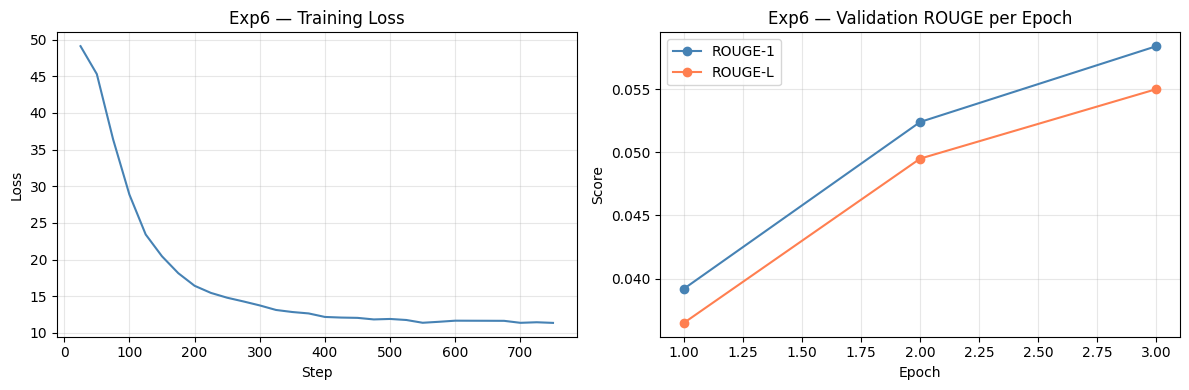

Plot saved


In [ ]:
history    = pd.DataFrame(trainer.state.log_history)
train_logs = history.dropna(subset=["loss"])
eval_logs  = history.dropna(subset=["eval_ROUGE1"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_logs["step"], train_logs["loss"], color="steelblue")
axes[0].set_title("Exp6 — Training Loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(eval_logs["epoch"], eval_logs["eval_ROUGE1"],
             marker="o", label="ROUGE-1", color="steelblue")
axes[1].plot(eval_logs["epoch"], eval_logs["eval_ROUGEL"],
             marker="o", label="ROUGE-L", color="coral")
axes[1].set_title("Exp6 — Validation ROUGE per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/plots/exp6_curves.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("Plot saved")

# Experiment 7: Higher LoRA Rank (r=16)

## What Changes From Experiment 6

We increase the LoRA rank from r=4 to r=16 and lora_alpha from 8 to 32.

In Experiments 4-6 with r=4, only 0.3% of model parameters were
trainable. The model was generating topically related text but failing
to learn the precise question-to-answer mapping — it knew the subject
area but could not generate focused answers.

LoRA rank controls the size of the adapter matrices inserted into the
attention layers. A higher rank means more trainable parameters and
more capacity to learn task-specific patterns.

r=16 increases trainable parameters to roughly 1.2% of the model.
lora_alpha is set to 32 (2x the rank) which is the standard scaling
convention — it keeps the effective learning rate of the adapter
matrices stable as rank increases.

Everything else is identical to Experiment 6 — same short prompt,
same dataset, same training arguments.

## Hypothesis

More trainable parameters will allow the model to learn more precise
question-answer mappings, producing more focused answers and higher
ROUGE scores than Experiment 6.

In [ ]:
!pip install -q torchao==0.16.0
!pip install -q transformers datasets evaluate accelerate peft sentencepiece rouge-score

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import transformers
from datasets import Dataset
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)
from peft import LoraConfig, TaskType, get_peft_model
from torch.utils.data import DataLoader

transformers.logging.set_verbosity_error()

In [ ]:
train_small = pd.read_csv("/content/drive/MyDrive/datasets/train_small2.csv")
val_small   = pd.read_csv("/content/drive/MyDrive/datasets/val_small2.csv")
test        = pd.read_csv("/content/drive/MyDrive/datasets/test_clean.csv")

LANGUAGE_MAP = {
    "Aka_Gha": "Akan",
    "Amh_Eth": "Amharic",
    "Lug_Uga": "Luganda",
    "Swa_Ken": "Swahili",
    "Eng_Eth": "English",
    "Eng_Gha": "English",
    "Eng_Ken": "English",
    "Eng_Uga": "English"
}

def apply_prompt(df):
    df = df.copy()
    df["input"] = df.apply(
        lambda row: f"health qa {LANGUAGE_MAP[row['subset']]}: {row['input']}",
        axis=1
    )
    return df

train_small = apply_prompt(train_small)
val_small   = apply_prompt(val_small)
test        = apply_prompt(test)

train_ds = Dataset.from_pandas(train_small)
val_ds   = Dataset.from_pandas(val_small)
test_ds  = Dataset.from_pandas(test)

print("train_ds:", len(train_ds))
print("val_ds  :", len(val_ds))
print("test_ds :", len(test_ds))
print()
print("Sample input:")
print(train_small["input"].iloc[0][:120])

train_ds: 4000
val_ds  : 1200
test_ds : 2618

Sample input:
health qa Akan: Mɛyɛ dɛn ahu sɛ nna ne abusuabɔ ho nsɛm a ɛwɔ Intanɛt so no yɛ nokware, na wotumi de ho to so?


In [ ]:
MODEL_NAME        = "google/mt5-small"
MAX_INPUT_LENGTH  = 128
MAX_TARGET_LENGTH = 192

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("pad_token_id:", tokenizer.pad_token_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


pad_token_id: 0


In [ ]:
def tokenize(examples):
    inputs = tokenizer(
        examples["input"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )
    targets = tokenizer(
        text_target=examples["output"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding=False
    )
    inputs["labels"] = [
        [t if t != tokenizer.pad_token_id else -100 for t in ids]
        for ids in targets["input_ids"]
    ]
    return inputs

def tokenize_test(examples):
    return tokenizer(
        examples["input"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )

tok_train = train_ds.map(tokenize,     batched=True, remove_columns=train_ds.column_names)
tok_val   = val_ds.map(tokenize,       batched=True, remove_columns=val_ds.column_names)
tok_test  = test_ds.map(tokenize_test, batched=True, remove_columns=test_ds.column_names)

print(tok_train)

lengths = [len(x) for x in tok_train["input_ids"]]
print(f"Input lengths — mean: {np.mean(lengths):.0f} | "
      f"95th pct: {np.percentile(lengths, 95):.0f} | "
      f"max: {max(lengths)}")

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/2618 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 4000
})
Input lengths — mean: 34 | 95th pct: 74 | max: 128


In [ ]:
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
model = model.float()

model.config.decoder_start_token_id = tokenizer.pad_token_id
model.config.forced_bos_token_id    = None

lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q", "v"],
    bias="none"
)

model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

trainable params: 688,128 || all params: 300,864,896 || trainable%: 0.2287


In [ ]:
collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
    pad_to_multiple_of=8
)

In [ ]:
rouge = evaluate.load("rouge")

def clean(text):
    return re.sub(r"<extra_id_\d+>", "", text).strip()

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    preds  = np.clip(preds, 0, tokenizer.vocab_size - 1)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_preds  = [clean(t) for t in
                      tokenizer.batch_decode(preds,  skip_special_tokens=True)]
    decoded_labels = tokenizer.batch_decode(labels,  skip_special_tokens=True)
    scores = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )
    return {
        "ROUGE1": round(scores["rouge1"], 4),
        "ROUGEL": round(scores["rougeL"], 4)
    }

In [ ]:
args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/checkpoints/exp7",

    num_train_epochs=3,
    learning_rate=3e-4,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,

    weight_decay=0.01,
    max_grad_norm=1.0,

    fp16=False,
    bf16=False,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="ROUGE1",
    greater_is_better=True,

    generation_max_length=192,
    generation_num_beams=1,

    predict_with_generate=True,

    logging_strategy="steps",
    logging_steps=25,
    save_total_limit=1,
    dataloader_num_workers=0,
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=tok_train,
    eval_dataset=tok_val,
    data_collator=collator,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

{'loss': '46.13', 'grad_norm': '556.7', 'learning_rate': '0.0002904', 'epoch': '0.1'}
{'loss': '32.63', 'grad_norm': '359.4', 'learning_rate': '0.0002804', 'epoch': '0.2'}
{'loss': '24.04', 'grad_norm': '93.81', 'learning_rate': '0.0002704', 'epoch': '0.3'}
{'loss': '18.3', 'grad_norm': '60.25', 'learning_rate': '0.0002604', 'epoch': '0.4'}
{'loss': '15.54', 'grad_norm': '8.76', 'learning_rate': '0.0002504', 'epoch': '0.5'}
{'loss': '14.4', 'grad_norm': '11.87', 'learning_rate': '0.0002404', 'epoch': '0.6'}
{'loss': '13.23', 'grad_norm': '17.34', 'learning_rate': '0.0002304', 'epoch': '0.7'}
{'loss': '12.49', 'grad_norm': '4.199', 'learning_rate': '0.0002204', 'epoch': '0.8'}
{'loss': '12.01', 'grad_norm': '1.59', 'learning_rate': '0.0002104', 'epoch': '0.9'}
{'loss': '11.57', 'grad_norm': '1.584', 'learning_rate': '0.0002004', 'epoch': '1'}
{'eval_loss': '4.222', 'eval_ROUGE1': '0.059', 'eval_ROUGEL': '0.0558', 'eval_runtime': '625.2', 'eval_samples_per_second': '1.919', 'eval_steps_p

TrainOutput(global_step=750, training_loss=13.860834187825521, metrics={'train_runtime': 2168.3693, 'train_samples_per_second': 5.534, 'train_steps_per_second': 0.346, 'train_loss': 13.860834187825521, 'epoch': 3.0})

In [ ]:
trainer.save_model("/content/drive/MyDrive/models/exp7/best_model")
tokenizer.save_pretrained("/content/drive/MyDrive/models/exp7/best_model")
print("Model saved")

Model saved


In [ ]:
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

val_loader = DataLoader(
    tok_val,
    batch_size=8,
    collate_fn=DataCollatorForSeq2Seq(
        tokenizer=tokenizer,
        model=model,
        padding=True,
        pad_to_multiple_of=8
    )
)

pred_text = []
ref_text  = []

for batch in val_loader:
    input_ids      = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels         = batch["labels"]

    with torch.no_grad():
        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=192,
            num_beams=1,
            decoder_start_token_id=tokenizer.pad_token_id,
            forced_bos_token_id=None,
            no_repeat_ngram_size=3
        )

    pred_text.extend([
        clean(t) for t in
        tokenizer.batch_decode(outputs, skip_special_tokens=True)
    ])

    labels = torch.where(labels != -100, labels, tokenizer.pad_token_id)
    ref_text.extend(
        tokenizer.batch_decode(labels, skip_special_tokens=True)
    )

print(f"Generated {len(pred_text)} predictions")

Generated 1200 predictions


In [ ]:
scores = rouge.compute(
    predictions=pred_text,
    references=ref_text,
    use_stemmer=True
)
print("ROUGE-1:", round(scores["rouge1"], 4))
print("ROUGE-L:", round(scores["rougeL"], 4))

ROUGE-1: 0.1033
ROUGE-L: 0.0846


In [ ]:
eng_indices = val_small[val_small["subset"].str.startswith("Eng")].index[:3].tolist()
aka_indices = val_small[val_small["subset"] == "Aka_Gha"].index[:2].tolist()

for i in aka_indices + eng_indices:
    print("="*70)
    print("LANGUAGE :", val_small.iloc[i]["subset"])
    print("QUESTION :", val_small.iloc[i]["input"][:150])
    print("REFERENCE:", ref_text[i][:200])
    print("GENERATED:", pred_text[i][:200])
    print()

LANGUAGE : Aka_Gha
QUESTION : health qa Akan: So amammerɛ anaa nyamesom mu nsusuwii ahorow bi wɔ hɔ a, ebetumi aka sɛnea awofo anaa abusuafo yɛ wɔn ade wɔ mmabun nna ne awo akwahos
REFERENCE: Yiw, amammerɛ ne nyamesom mu gyidi ahorow betumi anya sɛnea awofo anaa abusuafo yɛ wɔn ade wɔ mmabun nna ne awo akwahosan ho nsɛm ho no so nkɛntɛnso kɛse. Amammerɛ anaa ɔsom ahorow bi betumi asi ahobr
GENERATED: a nsɛm ho nsusuwii a, nsuwii nnsɛnea a wɔn a ne a.

LANGUAGE : Aka_Gha
QUESTION : health qa Akan: Dwuma bɛn na ahyehyɛde ahorow a egyina mpɔtamu hɔ, nhyehyɛe ahorow a mmabun di anim, ne atipɛnfo nkitahodi betumi adi wɔ mmabun nna ne
REFERENCE: Ahyehyɛde ahorow a egyina mpɔtamu hɔ, nhyehyɛe ahorow a mmabun di anim, ne atipɛnfo nkitahodi di dwuma titiriw wɔ mmabun nna ne awoɔ apomoden a wɔboa wɔ wiase nyinaa apomoden ho tebea horow a egye ntɛ
GENERATED: a wɔbɛboa wɔ nkitahodi a ɛbɛboa nkira a ne ayɛ nkɔmɛ a mu nɔbɛboa.

LANGUAGE : Eng_Eth
QUESTION : health qa English: Is it true that a blood

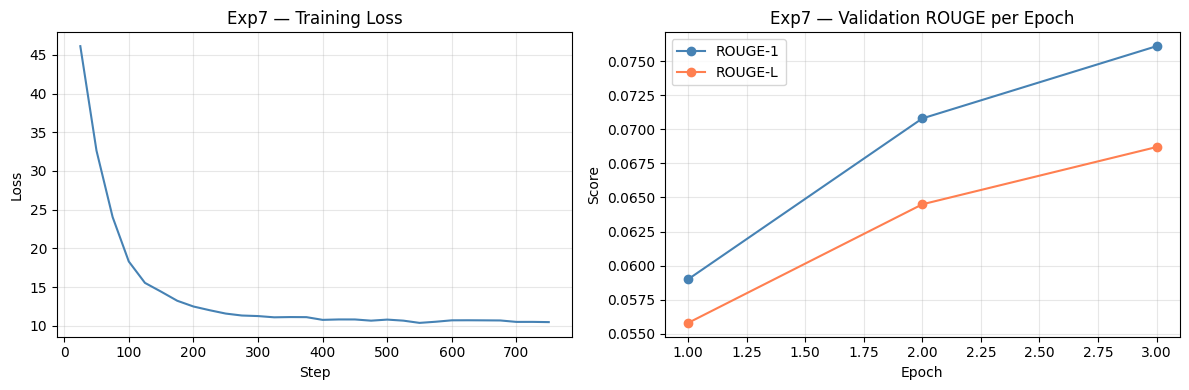

Plot saved


In [ ]:
history    = pd.DataFrame(trainer.state.log_history)
train_logs = history.dropna(subset=["loss"])
eval_logs  = history.dropna(subset=["eval_ROUGE1"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_logs["step"], train_logs["loss"], color="steelblue")
axes[0].set_title("Exp7 — Training Loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(eval_logs["epoch"], eval_logs["eval_ROUGE1"],
             marker="o", label="ROUGE-1", color="steelblue")
axes[1].plot(eval_logs["epoch"], eval_logs["eval_ROUGEL"],
             marker="o", label="ROUGE-L", color="coral")
axes[1].set_title("Exp7 — Validation ROUGE per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/plots/exp7_curves.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("Plot saved")

#Experiment 8

In [ ]:
!pip install -q torchao==0.16.0
!pip install -q transformers datasets evaluate accelerate peft sentencepiece rouge-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 53.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00


In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import transformers
from datasets import Dataset
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)
from peft import LoraConfig, TaskType, get_peft_model
from torch.utils.data import DataLoader

transformers.logging.set_verbosity_error()

In [ ]:
train_small = pd.read_csv("/content/drive/MyDrive/datasets/train_small2.csv")
val_small   = pd.read_csv("/content/drive/MyDrive/datasets/val_small2.csv")
test        = pd.read_csv("/content/drive/MyDrive/datasets/test_clean.csv")

LANGUAGE_MAP = {
    "Aka_Gha": "Akan",
    "Amh_Eth": "Amharic",
    "Lug_Uga": "Luganda",
    "Swa_Ken": "Swahili",
    "Eng_Eth": "English",
    "Eng_Gha": "English",
    "Eng_Ken": "English",
    "Eng_Uga": "English"
}

def apply_prompt(df):
    df = df.copy()
    df["input"] = df.apply(
        lambda row: f"health qa {LANGUAGE_MAP[row['subset']]}: {row['input']}",
        axis=1
    )
    return df

train_small = apply_prompt(train_small)
val_small   = apply_prompt(val_small)
test        = apply_prompt(test)

train_ds = Dataset.from_pandas(train_small)
val_ds   = Dataset.from_pandas(val_small)
test_ds  = Dataset.from_pandas(test)

print("train_ds:", len(train_ds))
print("val_ds  :", len(val_ds))
print("test_ds :", len(test_ds))
print()
print("Sample prompted input:")
print(train_small["input"].iloc[0])

train_ds: 4000
val_ds  : 1200
test_ds : 2618

Sample prompted input:
health qa Akan: Mɛyɛ dɛn ahu sɛ nna ne abusuabɔ ho nsɛm a ɛwɔ Intanɛt so no yɛ nokware, na wotumi de ho to so?


In [ ]:
MODEL_NAME        = "google/mt5-base"
MAX_INPUT_LENGTH  = 128
MAX_TARGET_LENGTH = 192

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("pad_token_id:", tokenizer.pad_token_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

pad_token_id: 0


In [ ]:
def tokenize(examples):
    inputs = tokenizer(
        examples["input"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )
    targets = tokenizer(
        text_target=examples["output"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding=False
    )
    inputs["labels"] = [
        [t if t != tokenizer.pad_token_id else -100 for t in ids]
        for ids in targets["input_ids"]
    ]
    return inputs

def tokenize_test(examples):
    return tokenizer(
        examples["input"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )

tok_train = train_ds.map(tokenize,     batched=True, remove_columns=train_ds.column_names)
tok_val   = val_ds.map(tokenize,       batched=True, remove_columns=val_ds.column_names)
tok_test  = test_ds.map(tokenize_test, batched=True, remove_columns=test_ds.column_names)

print(tok_train)
print()

# Verify nothing is being truncated aggressively
lengths = [len(x) for x in tok_train["input_ids"]]
print(f"Input lengths — mean: {np.mean(lengths):.0f} | "
      f"95th pct: {np.percentile(lengths, 95):.0f} | "
      f"max: {max(lengths)}")

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/2618 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 4000
})

Input lengths — mean: 34 | 95th pct: 74 | max: 128


In [ ]:
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
model = model.float()

model.config.decoder_start_token_id = tokenizer.pad_token_id
model.config.forced_bos_token_id    = None

lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=4,
    lora_alpha=8,
    lora_dropout=0.1,
    target_modules=["q", "v"],
    bias="none"
)

model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

pytorch_model.bin:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

trainable params: 442,368 || all params: 582,843,648 || trainable%: 0.0759


In [ ]:
collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
    pad_to_multiple_of=8
)

In [ ]:
rouge = evaluate.load("rouge")

def clean(text):
    return re.sub(r"<extra_id_\d+>", "", text).strip()

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    preds  = np.clip(preds, 0, tokenizer.vocab_size - 1)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_preds  = [clean(t) for t in
                      tokenizer.batch_decode(preds,  skip_special_tokens=True)]
    decoded_labels = tokenizer.batch_decode(labels,  skip_special_tokens=True)
    scores = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )
    return {
        "ROUGE1": round(scores["rouge1"], 4),
        "ROUGEL": round(scores["rougeL"], 4)
    }

In [ ]:
args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/checkpoints/exp8",

    num_train_epochs=3,
    learning_rate=3e-4,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,

    weight_decay=0.01,
    max_grad_norm=1.0,

    fp16=False,
    bf16=False,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="ROUGE1",
    greater_is_better=True,

    generation_max_length=192,
    generation_num_beams=1,

    predict_with_generate=True,

    logging_strategy="steps",
    logging_steps=25,
    save_total_limit=1,
    dataloader_num_workers=0,
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=tok_train,
    eval_dataset=tok_val,
    data_collator=collator,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

{'loss': '36.8', 'grad_norm': '6756', 'learning_rate': '0.0002904', 'epoch': '0.1'}
{'loss': '32.86', 'grad_norm': '2119', 'learning_rate': '0.0002804', 'epoch': '0.2'}
{'loss': '25.53', 'grad_norm': '663.1', 'learning_rate': '0.0002704', 'epoch': '0.3'}
{'loss': '19.77', 'grad_norm': '7206', 'learning_rate': '0.0002604', 'epoch': '0.4'}
{'loss': '16.24', 'grad_norm': '33.23', 'learning_rate': '0.0002504', 'epoch': '0.5'}
{'loss': '14.83', 'grad_norm': '35.99', 'learning_rate': '0.0002404', 'epoch': '0.6'}
{'loss': '13.29', 'grad_norm': '5.798', 'learning_rate': '0.0002304', 'epoch': '0.7'}
{'loss': '11.95', 'grad_norm': '61.07', 'learning_rate': '0.0002204', 'epoch': '0.8'}
{'loss': '11.02', 'grad_norm': '2.795', 'learning_rate': '0.0002104', 'epoch': '0.9'}
{'loss': '10.57', 'grad_norm': '11.48', 'learning_rate': '0.0002004', 'epoch': '1'}
{'eval_loss': '3.777', 'eval_ROUGE1': '0.0605', 'eval_ROUGEL': '0.0546', 'eval_runtime': '929.1', 'eval_samples_per_second': '1.292', 'eval_steps_

TrainOutput(global_step=750, training_loss=12.613646911621094, metrics={'train_runtime': 3654.4155, 'train_samples_per_second': 3.284, 'train_steps_per_second': 0.205, 'train_loss': 12.613646911621094, 'epoch': 3.0})

In [ ]:
trainer.save_model("/content/drive/MyDrive/models/exp8/best_model")
tokenizer.save_pretrained("/content/drive/MyDrive/models/exp8/best_model")
print("Model saved")

Model saved


In [ ]:
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

val_loader = DataLoader(
    tok_val,
    batch_size=8,
    collate_fn=DataCollatorForSeq2Seq(
        tokenizer=tokenizer,
        model=model,
        padding=True,
        pad_to_multiple_of=8
    )
)

pred_text = []
ref_text  = []

for batch in val_loader:
    input_ids      = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels         = batch["labels"]

    with torch.no_grad():
        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=192,
            num_beams=1,
            decoder_start_token_id=tokenizer.pad_token_id,
            forced_bos_token_id=None,
            no_repeat_ngram_size=3
        )

    pred_text.extend([
        clean(t) for t in
        tokenizer.batch_decode(outputs, skip_special_tokens=True)
    ])

    labels = torch.where(labels != -100, labels, tokenizer.pad_token_id)
    ref_text.extend(
        tokenizer.batch_decode(labels, skip_special_tokens=True)
    )

print(f"Generated {len(pred_text)} predictions")

Generated 1200 predictions


In [ ]:
scores = rouge.compute(
    predictions=pred_text,
    references=ref_text,
    use_stemmer=True
)
print("ROUGE-1:", round(scores["rouge1"], 4))
print("ROUGE-L:", round(scores["rougeL"], 4))

ROUGE-1: 0.1477
ROUGE-L: 0.1135


In [ ]:
eng_indices = val_small[val_small["subset"].str.startswith("Eng")].index[:3].tolist()
aka_indices = val_small[val_small["subset"] == "Aka_Gha"].index[:2].tolist()

for i in aka_indices + eng_indices:
    print("="*70)
    print("LANGUAGE :", val_small.iloc[i]["subset"])
    print("QUESTION :", val_small.iloc[i]["input"][:150])
    print("REFERENCE:", ref_text[i][:200])
    print("GENERATED:", pred_text[i][:200])
    print()

LANGUAGE : Aka_Gha
QUESTION : health qa Akan: So amammerɛ anaa nyamesom mu nsusuwii ahorow bi wɔ hɔ a, ebetumi aka sɛnea awofo anaa abusuafo yɛ wɔn ade wɔ mmabun nna ne awo akwahos
REFERENCE: Yiw, amammerɛ ne nyamesom mu gyidi ahorow betumi anya sɛnea awofo anaa abusuafo yɛ wɔn ade wɔ mmabun nna ne awo akwahosan ho nsɛm ho no so nkɛntɛnso kɛse. Amammerɛ anaa ɔsom ahorow bi betumi asi ahobr
GENERATED: a, etumi aka sɛnea awofo anaa abusuafo yɛ wɔn ade wɔ mmabun nna ne awofo yɛ ade a wɔn wɔn ho nsɛm mu nsusuwii ahorow bi wɔ hɔ a eyɛ wɔ nɔmfo nnɔfo nkɔ wɔ hɔn a. Ɛyɛ wɔ wɔn mu a ne wɔn ne wɔ wɔ ayɛ wɔm

LANGUAGE : Aka_Gha
QUESTION : health qa Akan: Dwuma bɛn na ahyehyɛde ahorow a egyina mpɔtamu hɔ, nhyehyɛe ahorow a mmabun di anim, ne atipɛnfo nkitahodi betumi adi wɔ mmabun nna ne
REFERENCE: Ahyehyɛde ahorow a egyina mpɔtamu hɔ, nhyehyɛe ahorow a mmabun di anim, ne atipɛnfo nkitahodi di dwuma titiriw wɔ mmabun nna ne awoɔ apomoden a wɔboa wɔ wiase nyinaa apomoden ho tebea horow a egye ntɛ
G

In [ ]:
history    = pd.DataFrame(trainer.state.log_history)
train_logs = history.dropna(subset=["loss"])
eval_logs  = history.dropna(subset=["eval_ROUGE1"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_logs["step"], train_logs["loss"], color="steelblue")
axes[0].set_title("Exp6 — Training Loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(eval_logs["epoch"], eval_logs["eval_ROUGE1"],
             marker="o", label="ROUGE-1", color="steelblue")
axes[1].plot(eval_logs["epoch"], eval_logs["eval_ROUGEL"],
             marker="o", label="ROUGE-L", color="coral")
axes[1].set_title("Exp6 — Validation ROUGE per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/plots/exp8_curves.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("Plot saved")